In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\water_pca.csv")
df = df.drop(columns = ['Unnamed: 0.1','Unnamed: 0'])

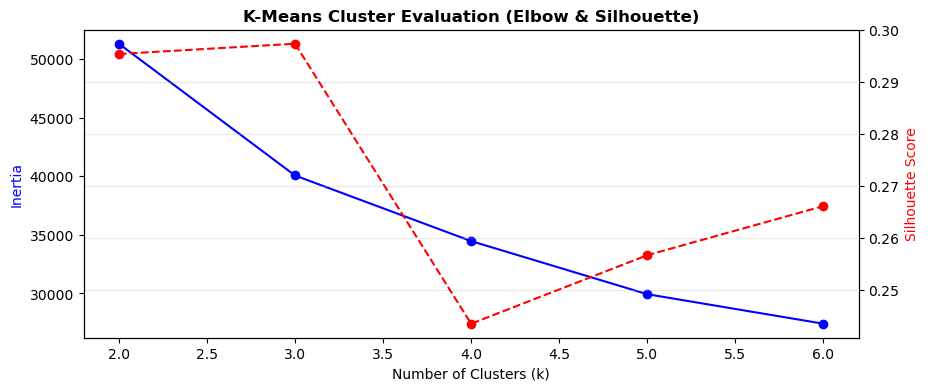

In [3]:
# Feature set for clustering
X_kmeans = df[['PC1', 'PC2', 'PC3']]

inertia = []
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_kmeans)
    
    inertia.append(kmeans.inertia_)
    # Sample up to 10k rows for fast silhouette evaluation
    sample_mask = np.random.choice(len(X_kmeans), size=min(10000, len(X_kmeans)), replace=False)
    silhouette_scores.append(silhouette_score(X_kmeans.iloc[sample_mask], cluster_labels[sample_mask]))

# Plotting Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(k_range, inertia, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'ro--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('K-Means Cluster Evaluation (Elbow & Silhouette)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
FEATURE_COLS = [
    'wtempV_°C', 
    'conductivity_of_solution_ mS_cm', 
    'oxidation_reduction_potential_ mV', 
    'turbidity_NTU', 
    'oxygen_saturation_%'
]

k_optimal = 3  # Adjust to 4 if indicated by Cell 1

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['PC1', 'PC2', 'PC3']])

print("=== CLUSTER SAMPLE COUNTS ===")
print(df['cluster'].value_counts())

print("\n=== CLUSTER MEANS (Original Physical Units) ===")
display(df.groupby('cluster')[FEATURE_COLS].mean().round(2))

=== CLUSTER SAMPLE COUNTS ===
cluster
2    6945
0    6535
1    4477
Name: count, dtype: int64

=== CLUSTER MEANS (Original Physical Units) ===


,wtempV_°C,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,turbidity_NTU,oxygen_saturation_%
cluster,,,,,
0,24.80,52705.75,135.78,158.34,65.10
1,25.27,51820.00,145.56,276.24,71.87
2,21.50,50620.77,152.48,166.28,59.39


In [5]:
# Cell: Map K-Means Clusters to Dashboard Target Status (Good / OK / Bad)
status_mapping = {
    0: 'Good',  # Clear baseline
    2: 'OK',    # Low oxygen / Transitional
    1: 'Bad'    # Severe turbidity / Storm event
}

df['water_quality_status'] = df['cluster'].map(status_mapping)

# Check class percentages for your ML model
print("=== Target Class Distribution ===")
print(df['water_quality_status'].value_counts(normalize=True).round(4) * 100)

=== Target Class Distribution ===
water_quality_status
OK      38.68
Good    36.39
Bad     24.93
Name: proportion, dtype: float64


In [ ]:
for var in FEATURE_COLS:
    groups = [
        df[df["cluster"] == c][var]
        for c in sorted(df["cluster"].unique())
    ]

    F, p = f_oneway(*groups)

    print(f"{var}")
    print(f"F = {F:.3f}, p = {p:.5f}\n")

wtempV_°C
F = 4838.989, p = 0.00000

conductivity_of_solution_ mS_cm
F = 70.535, p = 0.00000

oxidation_reduction_potential_ mV
F = 15.313, p = 0.00000

turbidity_NTU
F = 1063.829, p = 0.00000

oxygen_saturation_%
F = 347.463, p = 0.00000



In [12]:
model = ols("turbidity_NTU ~ C(cluster)", data=df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                  sum_sq       df            F  PR(>F)
C(cluster)  4.374228e+07      2.0  1063.828686     0.0
Residual    3.691144e+08  17954.0          NaN     NaN


In [13]:
eta2 = anova_table["sum_sq"]["C(cluster)"] / anova_table["sum_sq"].sum()

print(eta2)

0.10595028754115676


In [21]:
df.to_csv(r"C:\Users\User\Desktop\water\labeled_water_stats.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_7184\1983316184.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


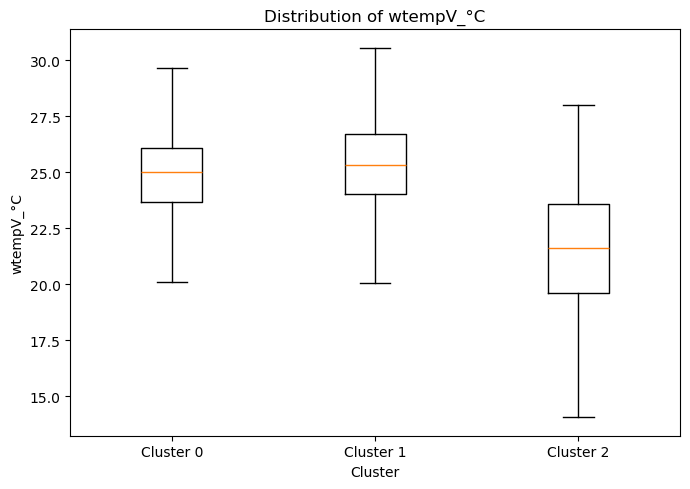

C:\Users\User\AppData\Local\Temp\ipykernel_7184\1983316184.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


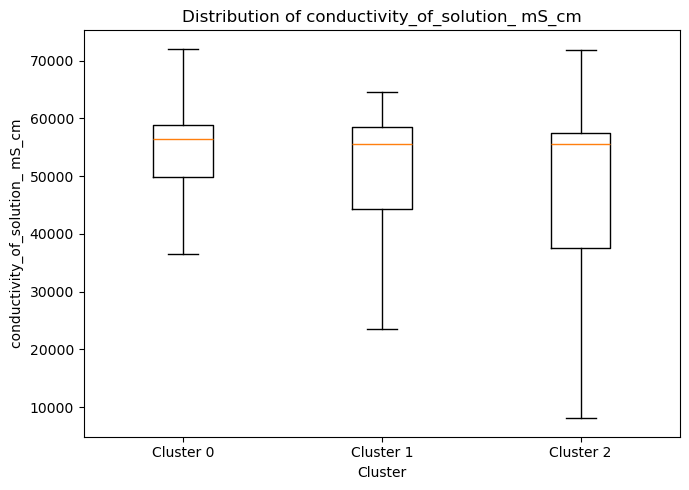

C:\Users\User\AppData\Local\Temp\ipykernel_7184\1983316184.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


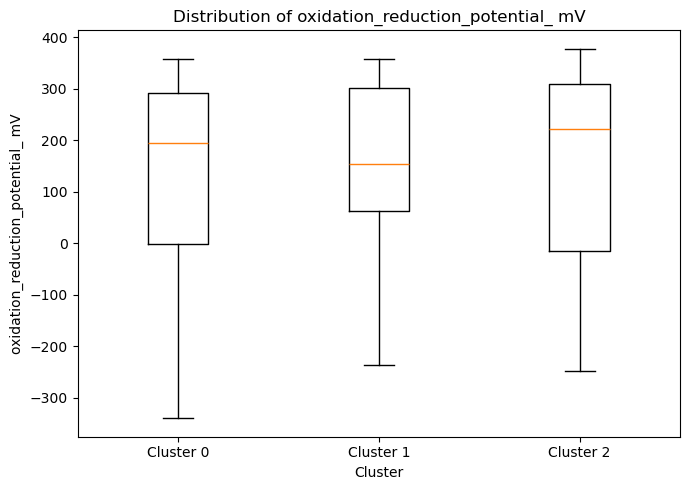

C:\Users\User\AppData\Local\Temp\ipykernel_7184\1983316184.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


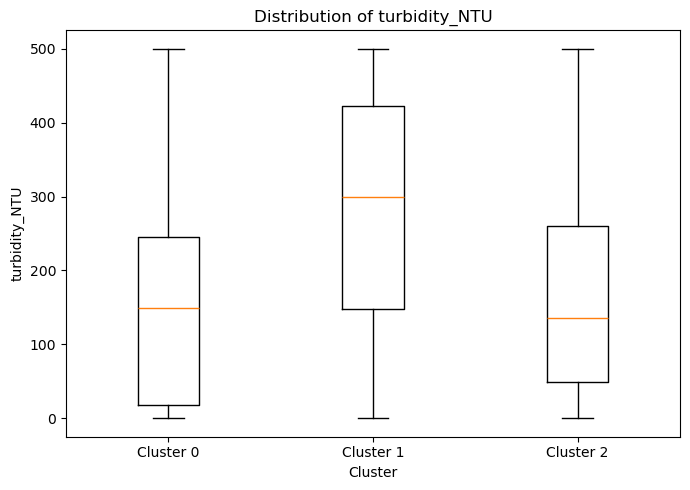

C:\Users\User\AppData\Local\Temp\ipykernel_7184\1983316184.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


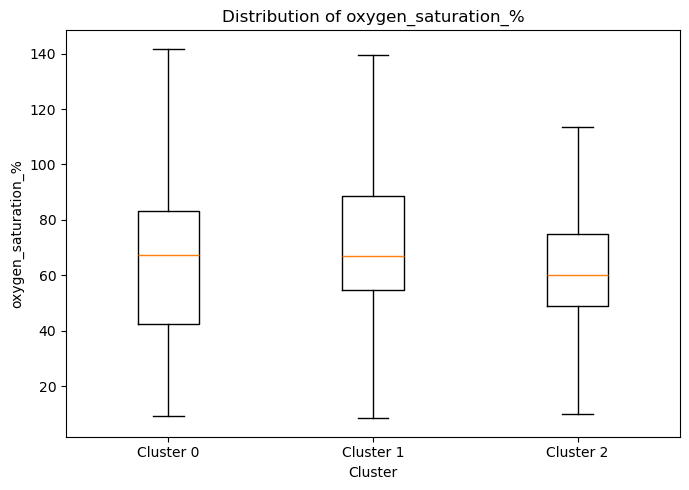

In [7]:
for var in FEATURE_COLS:
    plt.figure(figsize=(7,5))

    data = [df[df["cluster"] == c][var] for c in sorted(df["cluster"].unique())]

    plt.boxplot(
        data,
        labels=["Cluster 0", "Cluster 1", "Cluster 2"],
        showfliers=False   # Hide extreme outliers
    )

    plt.title(f"Distribution of {var}")
    plt.ylabel(var)
    plt.xlabel("Cluster")

    plt.tight_layout()
    plt.show()

In [12]:
df.groupby("cluster")[FEATURE_COLS].mean()

,wtempV_°C,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,turbidity_NTU,oxygen_saturation_%
cluster,,,,,
0,24.797420,52705.746548,135.776341,158.338283,65.101328
1,25.268232,51820.000080,145.560873,276.237592,71.869784
2,21.498943,50620.769116,152.484123,166.279507,59.386288
